### fiddling with density v r

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Annulus, Circle
from ugali.utils import projector

#defining centers and such
c_ra, c_dec = 53.53, -28.02
aper_r = 0.04

fake_peak_ra = np.random.normal(loc=c_ra, scale=0.01, size=(10,))
fake_peak_dec = np.random.normal(loc=c_dec, scale=0.01, size=(10,))
peak_angsep = projector.angsep(c_ra, c_dec, 
                               fake_peak_ra, fake_peak_dec)

mesh_ra = np.linspace(53.45, 53.625)
mesh_dec = np.linspace(-27.94, -28.09)
#mesh_coords = SkyCoord(ra=mesh_ra*u.deg,dec=mesh_dec*u.deg, frame='icrs')
#mesh_x, mesh_y = wcs.world_to_pixel(mesh_coords)
unif_ra, unif_dec = np.meshgrid(mesh_ra, mesh_dec)
uniform_angsep = projector.angsep(c_ra, c_dec,
                                  unif_ra, unif_dec)

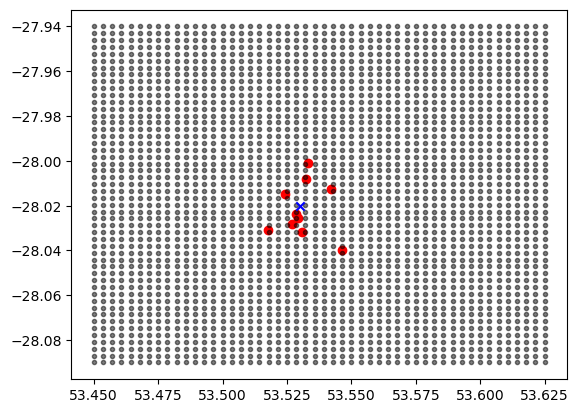

In [3]:
plt.scatter(fake_peak_ra, fake_peak_dec, marker = 'o', color = 'r')
plt.scatter(unif_ra, unif_dec, marker = '.', color = 'k', alpha=0.5)
plt.scatter(c_ra, c_dec, marker = 'x', color = 'b')

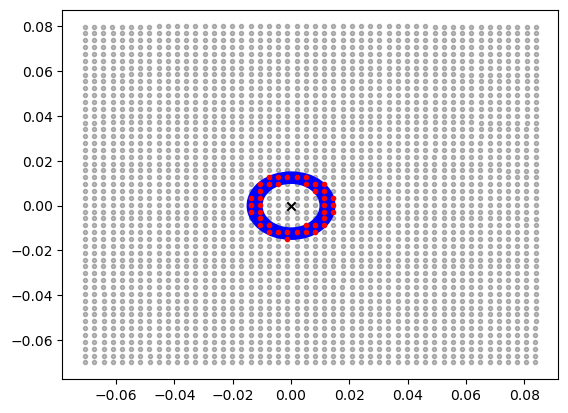

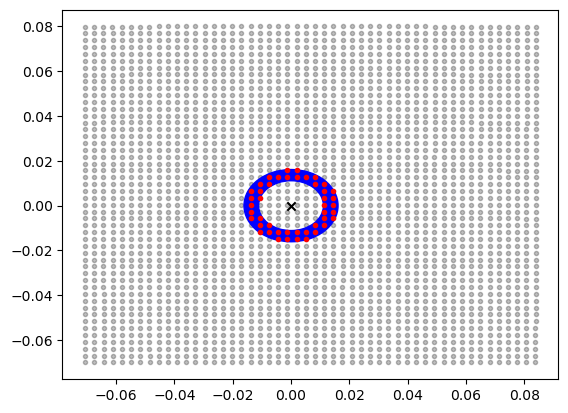

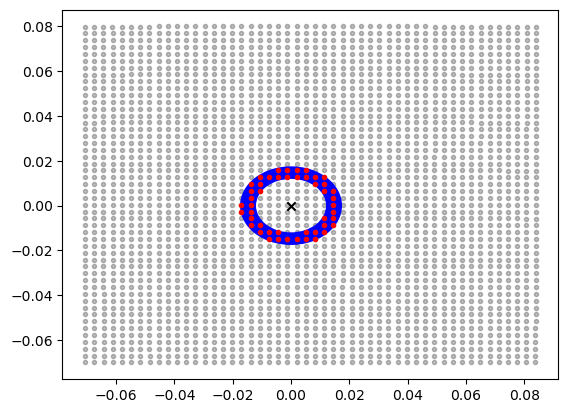

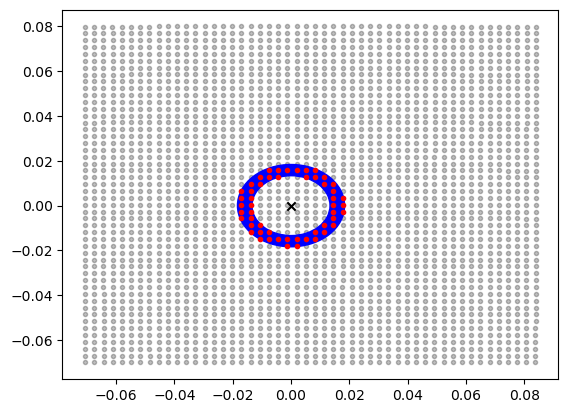

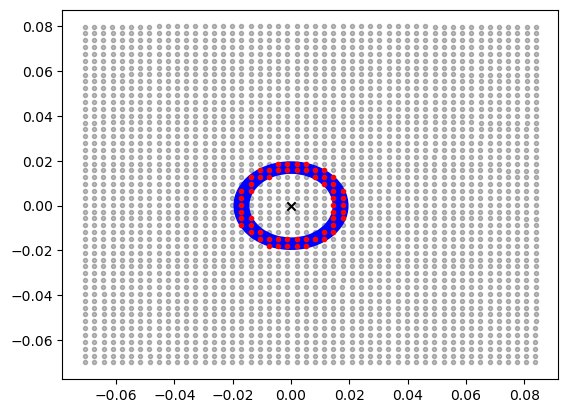

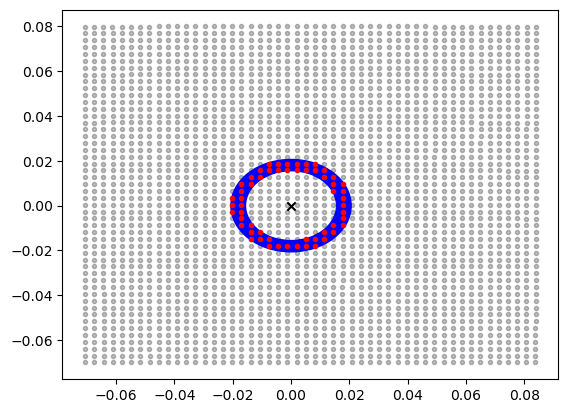

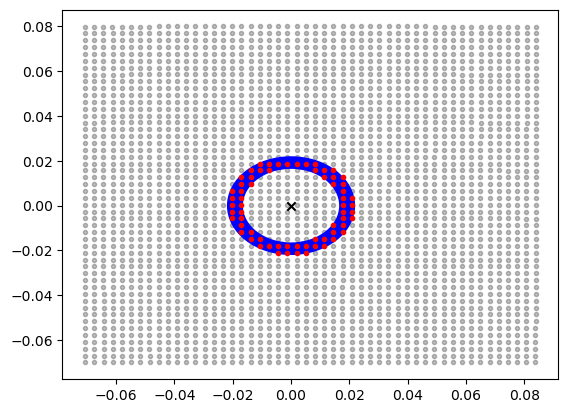

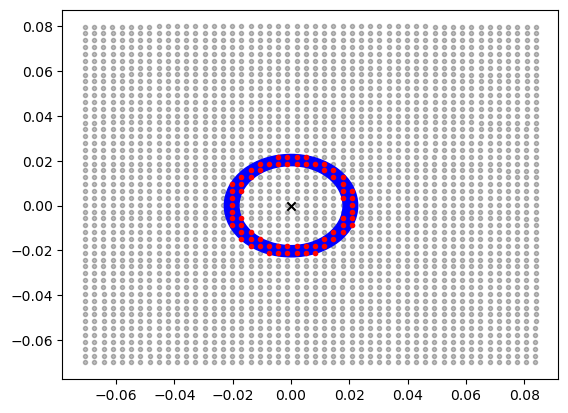

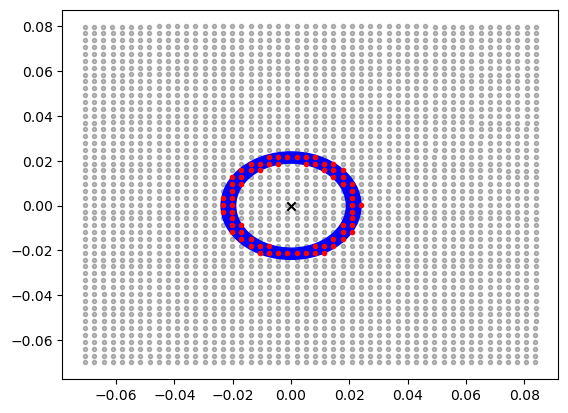

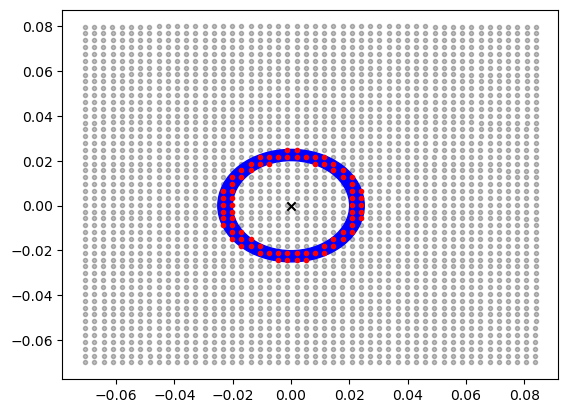

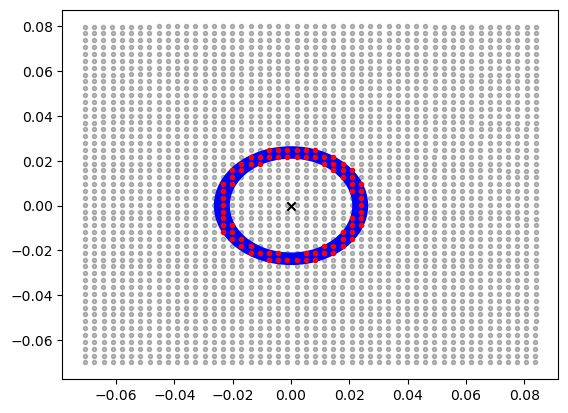

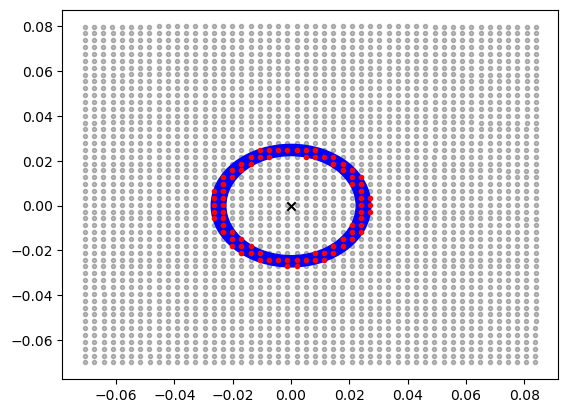

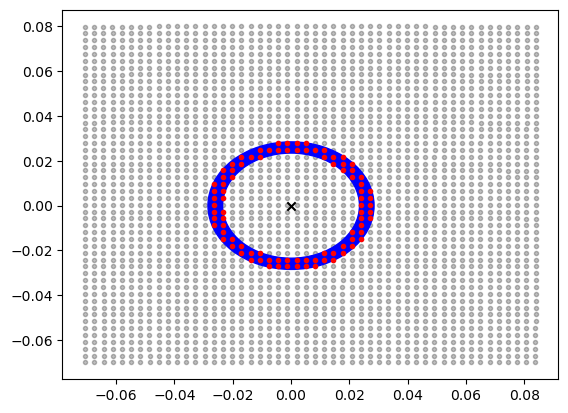

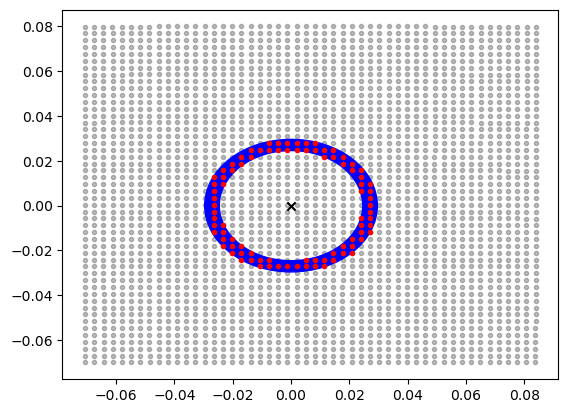

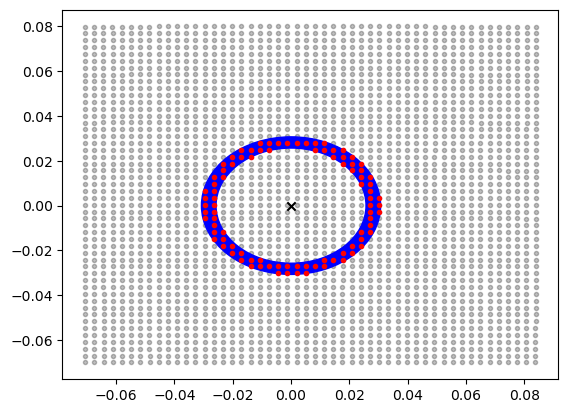

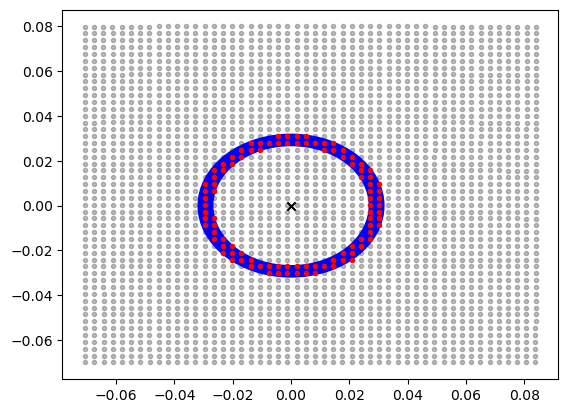

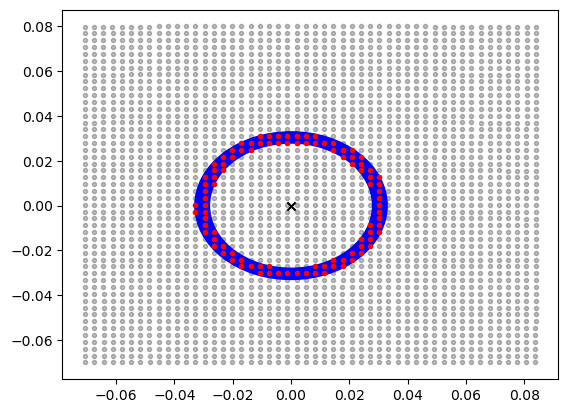

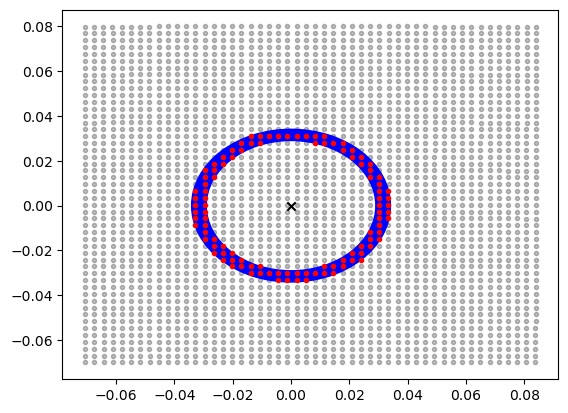

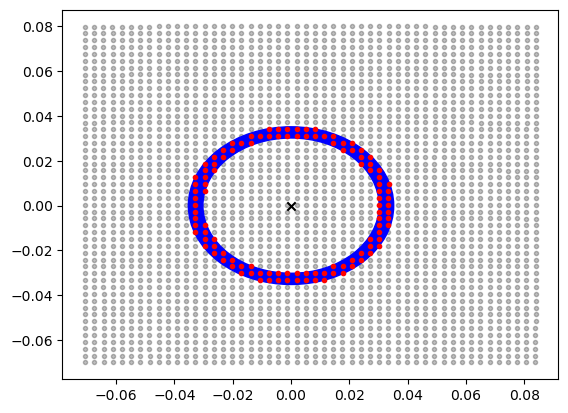

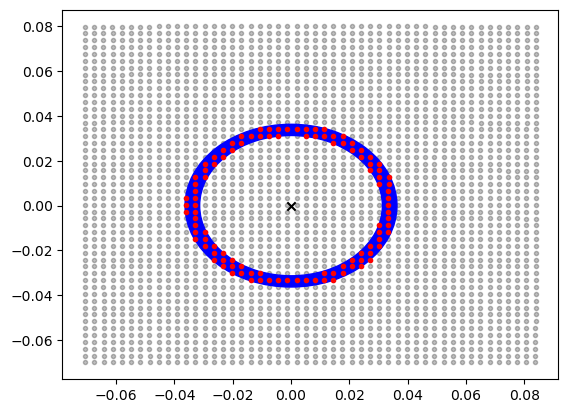

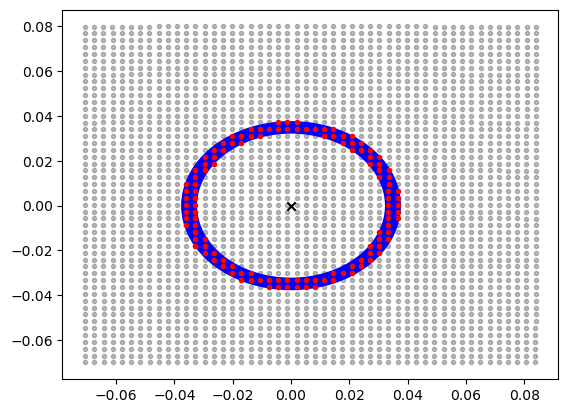

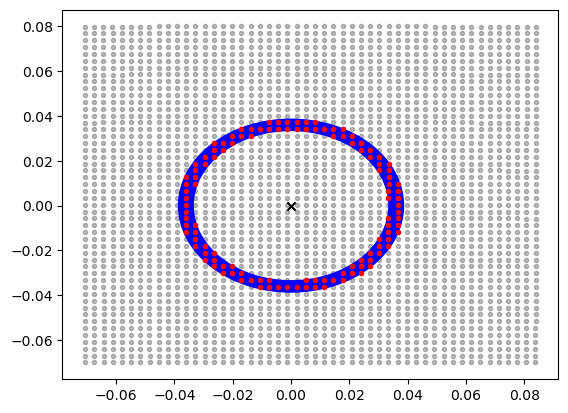

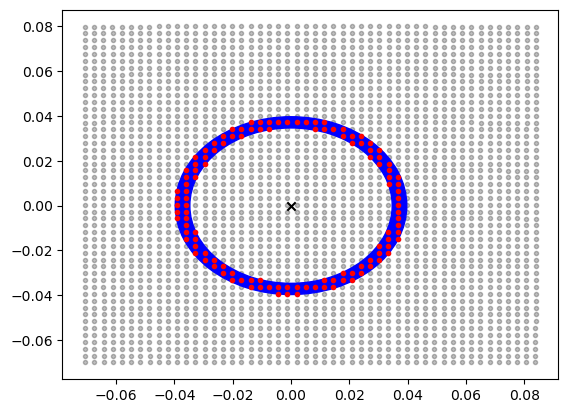

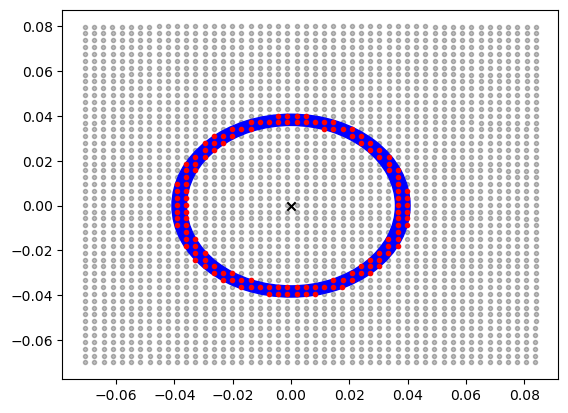

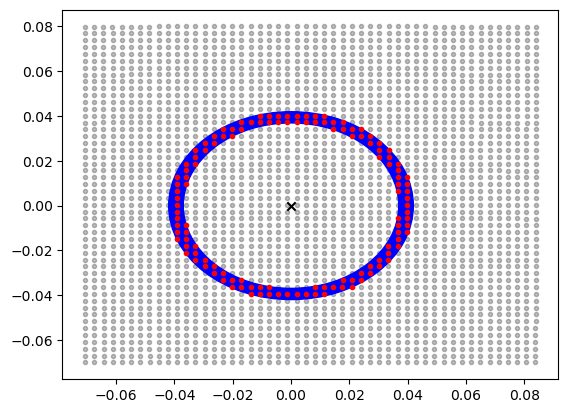

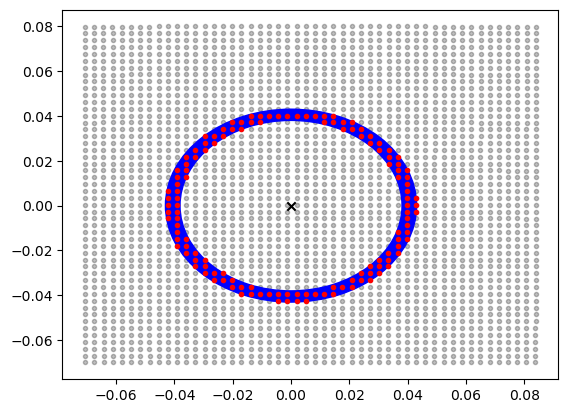

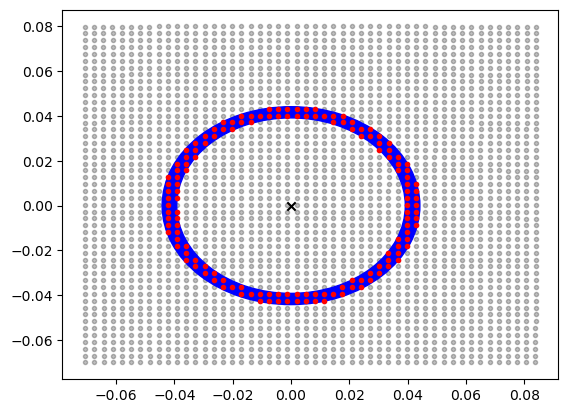

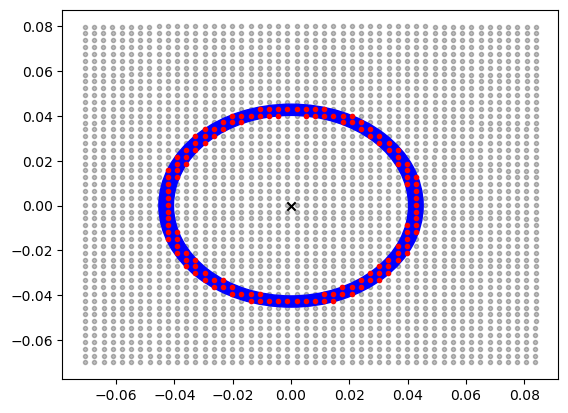

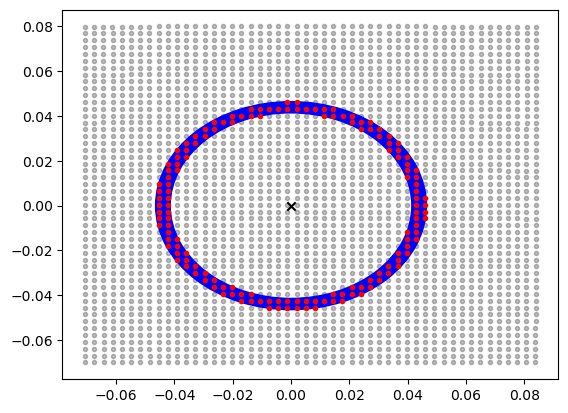

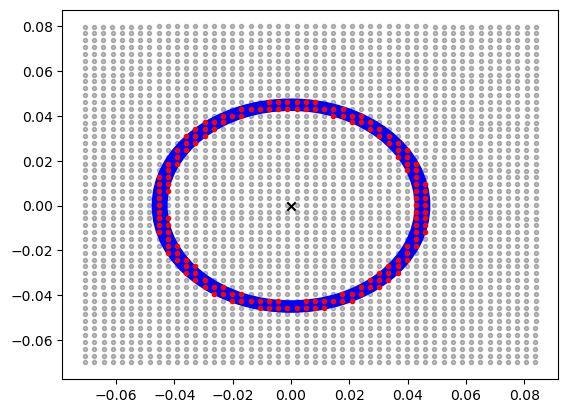

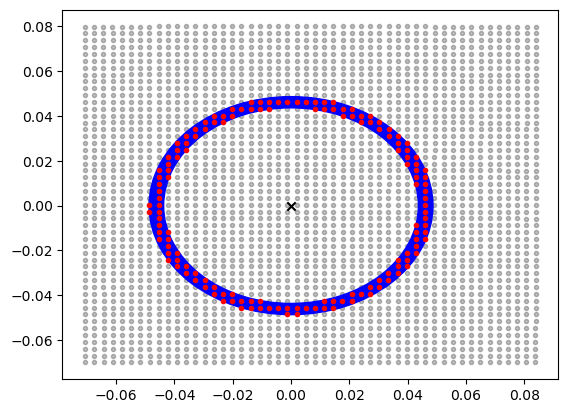

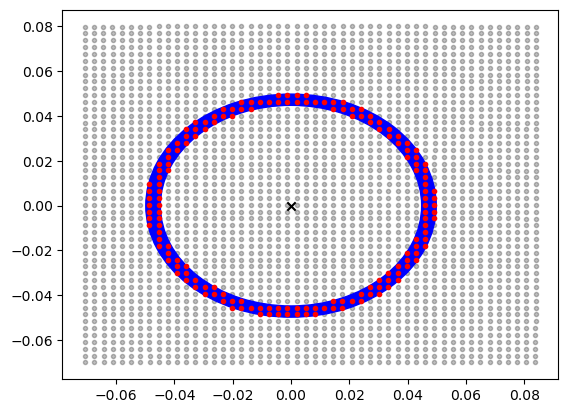

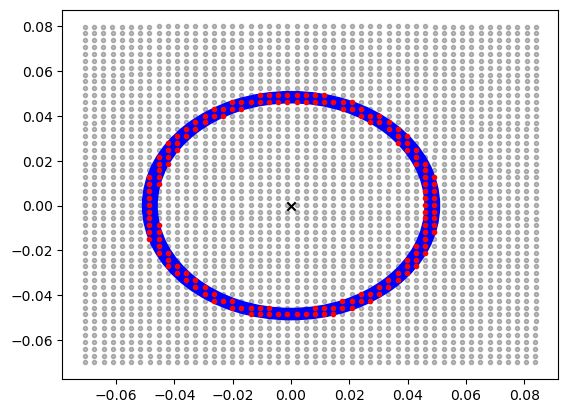

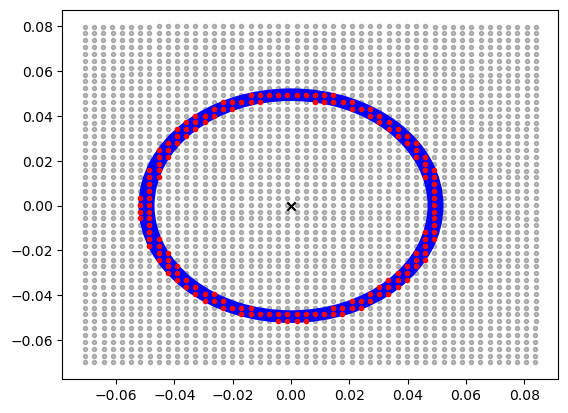

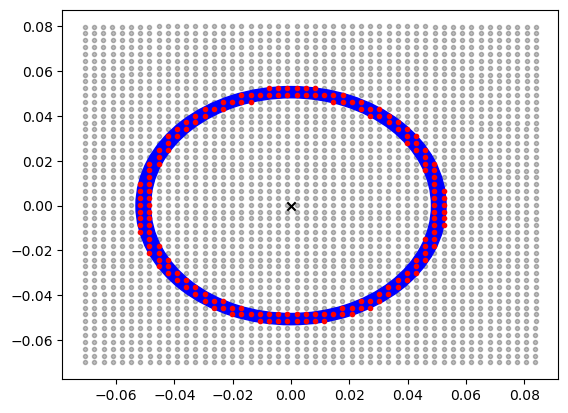

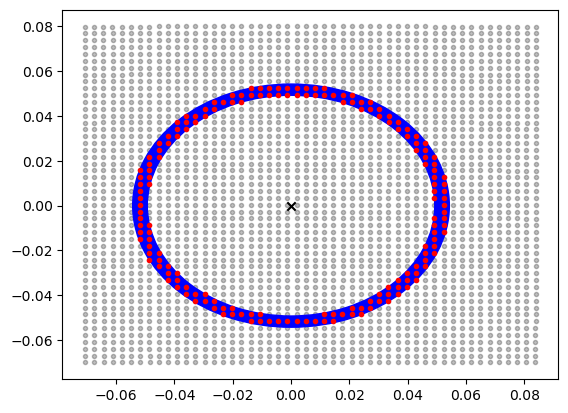

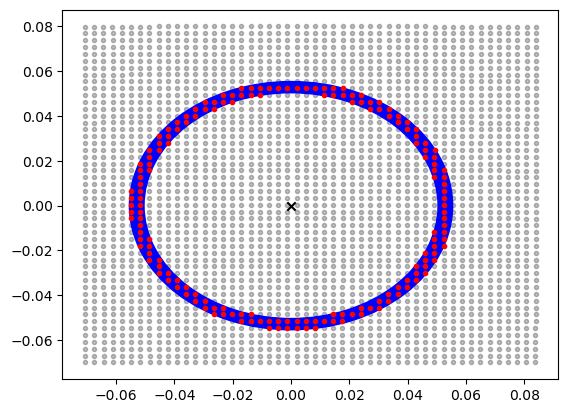

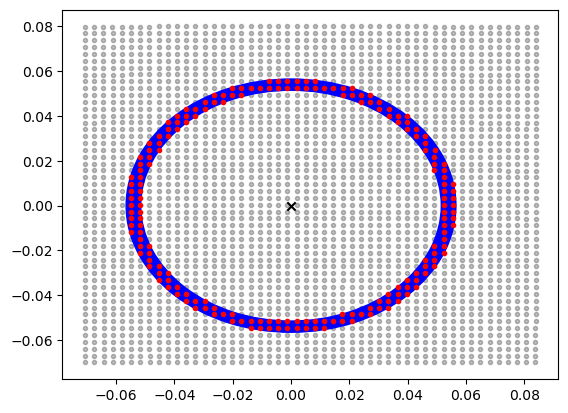

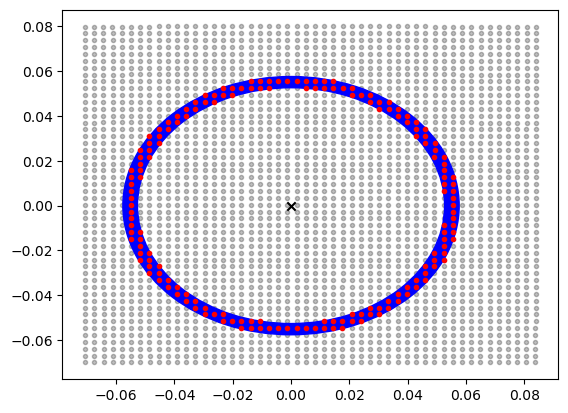

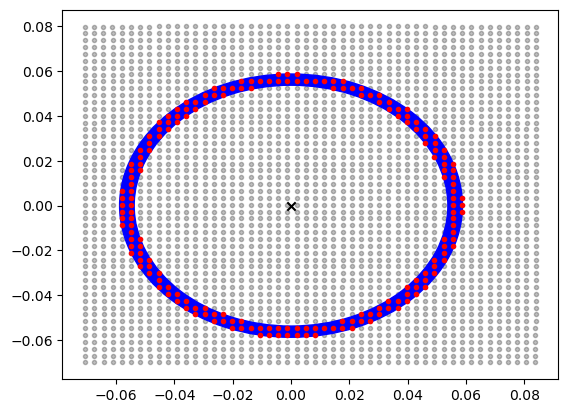

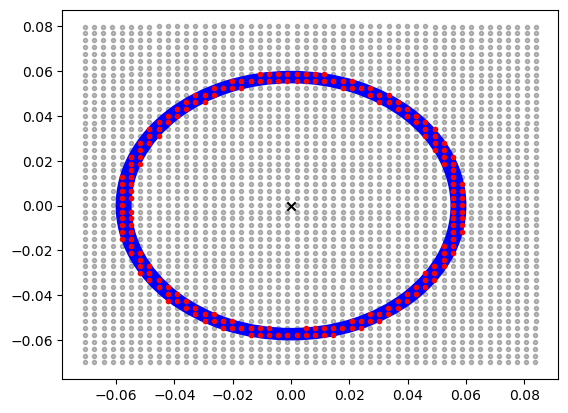

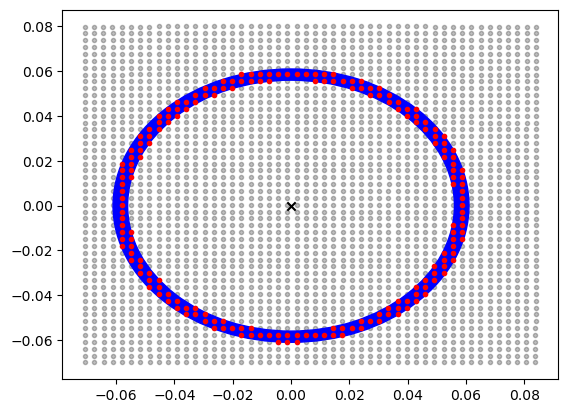

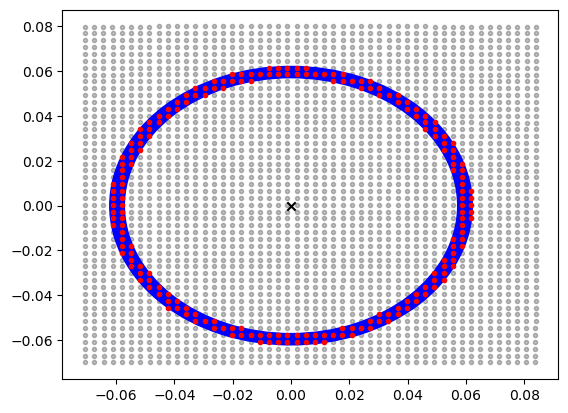

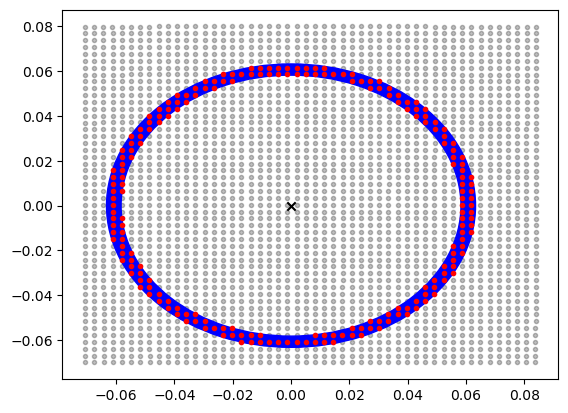

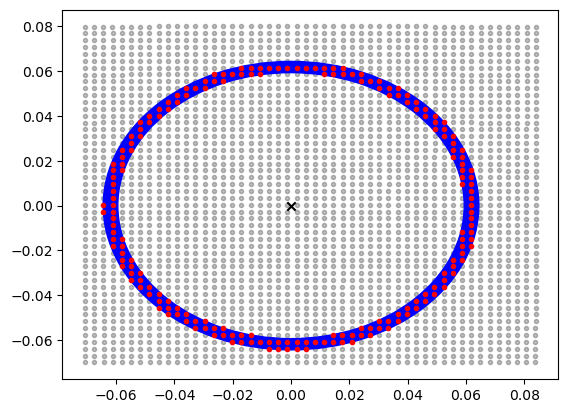

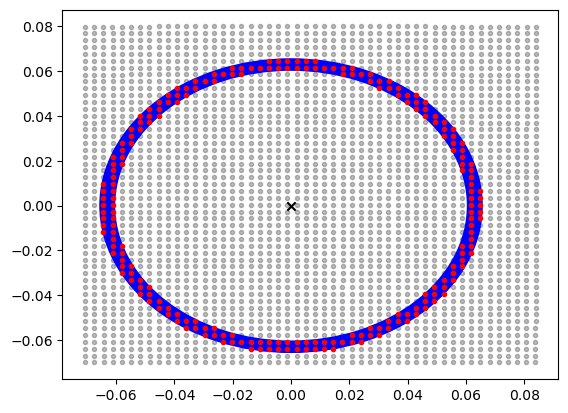

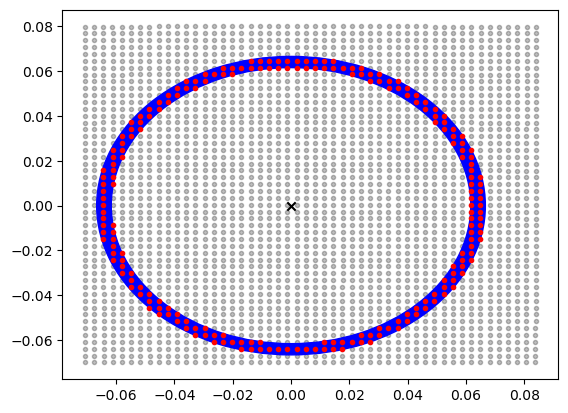

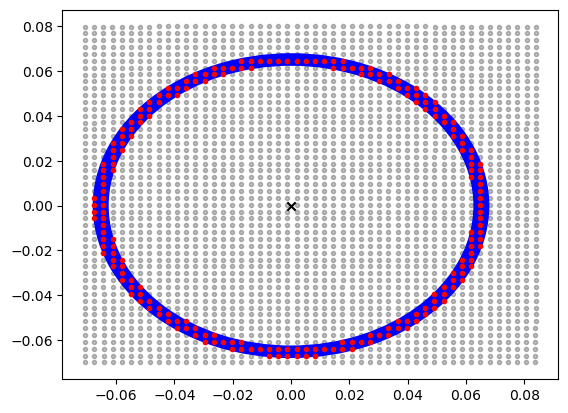

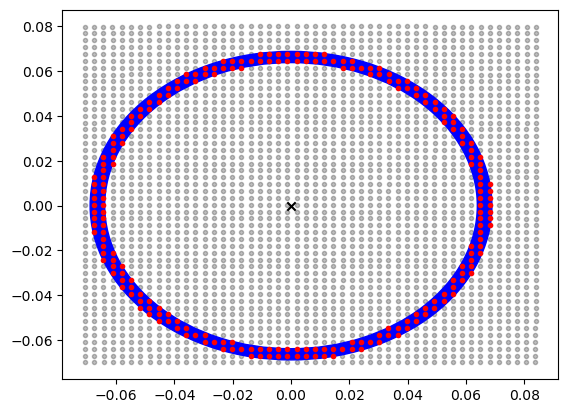

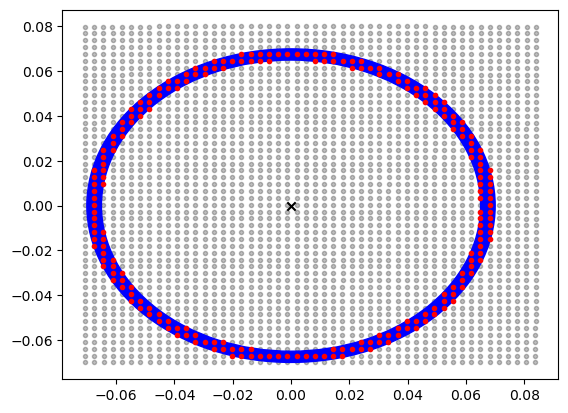

In [14]:
unif_x, unif_y = projector.sphere2image(c_ra,c_dec,unif_ra,unif_dec)
c_x,c_y = projector.sphere2image(c_ra,c_dec,c_ra,c_dec)

density_peak = []
density_uniform = []

radii = np.linspace(0.015,0.07,50)
for r in radii:
    r2 = r-0.005
    area = np.pi*(r**2) - np.pi*(r2**2)

    fig, ax = plt.subplots()
    ax.scatter(unif_x, unif_y, marker = '.', color = 'k', alpha=0.25)
    #ax.scatter(fake_peak_ra, fake_peak_dec, marker = 'o', color = 'r')
    #circle = plt.Circle((c_x,c_y), r, color='b')
    circle = Annulus((c_x,c_y), r, 0.005, color='b')
    ax.add_patch(circle)
    ax.scatter(c_x,c_y, marker = 'x', color = 'k')
    unif_mask = (uniform_angsep<=r)&(uniform_angsep>=r2)
    ax.scatter(unif_x[unif_mask],unif_y[unif_mask],marker='.',color='r')
    plt.show()
    
    uniform_within = np.sum(unif_mask)
    density_uniform.append(uniform_within / area)
    #print(uniform_within, area, uniform_within / area)
    
    peak_mask = (peak_angsep<=r)&(peak_angsep>=r2)
    peak_within = np.sum(peak_mask)
    density_peak.append(peak_within / area)

In [15]:
density_uniform = np.array(density_uniform)
unif_area2 = np.mean(density_uniform)*(radii[-1]-radii[0])
norm_unif2 = density_uniform/unif_area2

density_peak = np.array(density_peak)
peak_area = np.trapezoid(density_peak, x=radii)
norm_peak = density_peak/peak_area

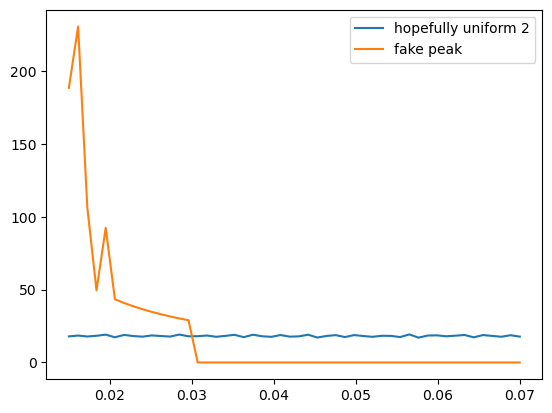

In [17]:
#plt.plot(radii, norm_unif, label='hopefully uniform')
plt.plot(radii, norm_unif2, label='hopefully uniform 2')
plt.plot(radii, norm_peak, label='fake peak')
plt.legend()

### fiddling with dropping duplicate peaks

In [ ]:
from alfred import DataObjects

distance_array = np.arange(50,1000,50) #distance is given in kpc
ra_peak_array = np.linspace(5,10,5)
dec_peak_array = np.linspace(5,10,5)
r_peak_array = np.linspace(5,10,5)
sig_peak_array = np.linspace(5,10,5)
distance_modulus_array = np.linspace(5,10,5)
n_obs_peak_array = np.linspace(5,10,5)
n_obs_half_peak_array = np.linspace(5,10,5)
n_model_peak_array = np.linspace(5,10,5)

results = np.asarray((ra_peak_array, dec_peak_array, 
                         r_peak_array, sig_peak_array, distance_modulus_array, 
                         n_obs_peak_array, n_obs_half_peak_array, n_model_peak_array))


In [ ]:
Peaks = []

for distance in distance_array:
    results = np.asarray((ra_peak_array, dec_peak_array, 
                         r_peak_array, sig_peak_array, distance_modulus_array, 
                         n_obs_peak_array, n_obs_half_peak_array, n_model_peak_array))
            #survey isn't actually used? so maybe just str?
            #region is an object, I think I've added all the attributes and methods necessary to use their functions
    one_peak_per_row = results.T
    peak_number = np.shape(one_peak_per_row)[0]
    if peak_number==0:
        continue
    for i in range(peak_number):
        #ra_peak, dec_peak, r_peak, sig_peak, distance_modulus, n_obs_peak, n_obs_half_peak, n_model_peak = results_transpose[i]        
        Peaks.append(DataObjects.Peak(one_peak_per_row[i]))
if len(Peaks)==0:
    print('no peaks here')
else:
    print('before sorting, sigma_0 = ', Peaks[0].sig, ' sigma_-1 = ', Peaks[-1].sig)
    Peaks.sort(key=lambda x: x.sig, reverse=True)
    print('after sorting, sigma_0 = ', Peaks[0].sig, ' sigma_-1 = ', Peaks[-1].sig)

In [ ]:
import itertools
from ugali.utils import projector

In [ ]:
# option 1
moresig_Peaks = []
for i in range(len(Peaks)):
    overlaps = []
    for j in range(len(Peaks)):
        if i==j:
            continue
        else:
            angsep = projector.angsep(Peaks[i].ra, Peaks[i].dec, Peaks[j].ra, Peaks[j].dec)
            if angsep<Peaks[i].r:
                overlaps.append(Peaks[j])
    mostsig_Peak_i = max(overlaps, key=lambda x: x.sig)
    moresig_Peaks.append(mostsig_Peak_i.id)
moresig_Peaks

In [ ]:
# option 2
moresig_Peaks = []
for Peak1,Peak2 in itertools.combinations(Peaks,2):
    angsep = projector.angsep(Peak1.ra, Peak1.dec, Peak2.ra, Peak2.dec)
    if angsep<Peak1.r:
        two_peaks_sig = np.array([Peak1.sig, Peak2.sig])
        two_peaks = [Peak1,Peak2]
        moresig_Peak = two_peaks[np.argmax(two_peaks_sig)]
        #print('peaks 1 and 2: ', Peak1.id, ' | ', Peak2.id)
        #print('peak being appended: ', moresig_Peak.id)
        moresig_Peaks.append(moresig_Peak)
        moresig_Peak.overlapping_peaks.append(two_peaks[np.argmin(two_peaks_sig)])

#moresig_Peaks = list(set(moresig_Peaks))


In [ ]:
from astropy import units as u
import time

In [ ]:
#t0 = time.time()
Peaks = []
a = np.array([Peak.make_tuple() for Peak in Peaks])
arrtable = Table(a, names=Peaks[0].list_labels(return_type='tuple units'))
#t1 = time.time()
#t1-t0
arrtable

In [ ]:
t0 = time.time()
t = QTable()
t['peak_id'] = [f'{int(Peak.ra)}.{int(Peak.dec)}.{int(Peak.distance)}' for Peak in Peaks]
t['ra'] = [Peak.ra for Peak in Peaks] * u.deg
t['dec'] = [Peak.dec for Peak in Peaks] * u.deg
t['r'] = [Peak.r for Peak in Peaks] * u.deg
t['sig'] = [Peak.sig for Peak in Peaks]
t['distance'] = [Peak.distance for Peak in Peaks] * u.kpc
t['distance_modulus'] = [Peak.distance_modulus for Peak in Peaks] * u.mag
t['n_obs'] = [Peak.n_obs for Peak in Peaks]
t['n_obs_half'] = [Peak.n_obs_half for Peak in Peaks]
t['n_model'] = [Peak.n_model for Peak in Peaks]
t1 = time.time()
t1-t0

### fiddling with healsparse maps

Take a look at healsparse maps generated by the DM pipelines.

There is also a nice tutorial given [here](https://github.com/LSSTDESC/healsparse/blob/main/tutorial/quickstart.ipynb), with documentation [here](https://healsparse.readthedocs.io/en/stable/index.html). 

I also have some example code I've used for the cell-based coadds [here](https://github.com/mirarenee/notebooks/blob/main/cell_coadds/technote/healsparse-plots.ipynb).

In [ ]:
import healsparse as hsp
import healpy as hp
from hpgeom import hpgeom
import skyproj
import ugali.utils.healpix as healpix

from matplotlib import pyplot as plt
import numpy as np
import pandas as pd

from lsst.daf.butler import Butler
from alfred import utils, RegionObjects

import lsst.geom as geom

In [ ]:
%env DAF_BUTLER_REPOSITORY_INDEX=/global/cfs/cdirs/lsst/production/gen3/shared/data-repos.yaml

In [ ]:
def buffer_region(ra_corners, dec_corners, center, scale=1.2):
    ra_recentered, dec_recentered = ra_corners-center[0], dec_corners-center[1]
    ra_rescaled, dec_rescaled = scale*ra_recentered, scale*dec_recentered
    ra_new, dec_new = ra_rescaled+center[0], dec_rescaled+center[1]
    return ra_new, dec_new

In [ ]:
nside=64
ra_og, dec_og = 53.16, -28.10
pixel = healpix.ang2pix(nside, ra_og, dec_og)
ra,dec = healpix.pix2ang(nside, pixel)
center = (ra,dec)
ra_arr, dec_arr = hp.vec2ang(hp.boundaries(nside, pixel, step=1, nest=False).T, lonlat=True)

ra_new, dec_new = buffer_region(ra_arr, dec_arr, center,scale=1.1)

In [ ]:
#get pixels in buffer region
vec_arr = healpix.ang2vec(ra_new, dec_new)
ra_postvec, dec_postvec = hp.vec2ang(vec_arr)
fine_nside=4096
poly_pixels = hp.query_polygon(fine_nside,vec_arr,inclusive=True)
poly_ra, poly_dec = healpix.pix2ang(fine_nside, poly_pixels)

In [ ]:
plt.plot(ra_arr, dec_arr, label = 'Original Corner of the Pixel',c='k')
plt.scatter(center[0],center[1], label = 'Center of the Pixel',c='k')
plt.scatter(ra_og, dec_og, label = 'Original Coordinate',c='g')
plt.plot(ra_new, dec_new, label = 'Rescaled and recentered corners',c='C0')
plt.scatter(poly_ra, poly_dec, label='Query Polygon',c='C1')
plt.legend(loc = (1.1,0.8))

In [ ]:
# define collection parameters
REPO = 'dp2'

butler = Butler(REPO)
registry = butler.registry

# I don't think this dp2 repo was chained? So each stage was needed to be read at separate collections
collection = 'dp2'

In [ ]:
SkyMap =  butler.get('skyMap', skymap='lsst_cells_v2', collections=collection)
TractInfo = SkyMap.findTract(geom.SpherePoint(53.780487805*geom.degrees,-49*geom.degrees))
TractInfo.tract_id

In [ ]:
ra, dec = hp.vec2ang(hp.boundaries(32, 120, step=1, nest=False).T, lonlat=True)
print(type(ra))
print(dec)

In [ ]:
string = ''
for ra, dec in zip(ra,dec):
    string += f'{ra}, {dec}, '
string = string.removesuffix(', ')
string

## Reading in a healsparse map

Let's first see what's available.

In [ ]:

for datasetType in registry.queryDatasetTypes():
    if registry.queryDatasets(datasetType, collections=collection).any(execute=False, exact=False):
        if "map" in datasetType.name: #and "maglim" in datasetType.name:
            print(datasetType)


For each type of map, there is both a `HealSparseMap` available, as well as an associated plot. The plot might be helpful for sanity checks, but the `HealSparseMap` is more what we're looking for.

Above cell prints:  
DatasetType('deepCoadd_psf_maglim_map_weighted_mean', {band, skymap, tract}, HealSparseMap)  
DatasetType('deepCoadd_psf_maglim_consolidated_map_weighted_mean', {band, skymap}, HealSparseMap)  
DatasetType('propertyMapSurvey_deepCoadd_psf_maglim_consolidated_map_weighted_mean_SurveyWidePropertyMapPlot', {band, skymap}, Plot)  
DatasetType('propertyMapTract_deepCoadd_psf_maglim_map_weighted_mean_PerTractPropertyMapPlot', {band, skymap, tract}, Plot)

In [ ]:
'''
target_names = []
for ref in butler.registry.queryDatasets('direct_warp',
                                         collections=collection,
                                         instrument='LSSTCam',
                                         band='i',
                                         tract=2234,
                                         skymap='lsst_cells_v2',).expanded():
    target_names.append(ref.dataId.records["visit"].target_name)
target_names = np.unique(target_names)
print(target_names)
'''

In [ ]:
'''
tracts_a = []
tracts_b = []
for ref in butler.registry.queryDatasets('direct_warp',
                                         collections=collection,
                                         instrument='LSSTCam',
                                         skymap='lsst_cells_v2',
                                         where="visit.target_name IN ('DDF EDFS_a, lowdust')"):
    tracts_a.append(ref.dataId['tract'])
for ref in butler.registry.queryDatasets('direct_warp',
                                         collections=collection,
                                         instrument='LSSTCam',
                                         skymap='lsst_cells_v2',
                                         where="visit.target_name IN ('DDF EDFS_b, lowdust')"):
    tracts_b.append(ref.dataId['tract'])
np.unique(tracts_a+tracts_b)
'''

In [ ]:
ecdfs_tract_list = [4848, 4849, 5063, 4636, 4637, 4638, 4847, 4850, 5061, 5062, 5064,
       5065, 5279, 5280, 5281, 5282]
edfs_tract_list = [2078, 2079, 2080, 2232, 2233, 2234, 2235, 2236, 2237, 2392, 2393,
       2394, 2395, 2396, 2397, 2557, 2558, 2559, 2560, 2561, 2562, 2728,
       2729, 2730, 2731]

In [ ]:
#nside = 2048
'''
entire_hsp_map = butler.get('deepCoadd_psf_maglim_consolidated_map_weighted_mean',
                     collections = collection,
                     band = 'i',
                     skymap = 'lsst_cells_v2',
                     parameters={"degrade_nside": 32},)
map_mask = hsp.HealSparseMap.make_empty(entire_hsp_map.nside_sparse, entire_hsp_map.nside_coverage, np.uint16)
'''

In [ ]:
ecdfs_list = []
for i in range(len(ecdfs_tract_list)):
    ecdfs_list.append(butler.get('deepCoadd_psf_maglim_map_weighted_mean',
                                    collections = collection,
                                    band = 'i',
                                    skymap = 'lsst_cells_v2', 
                                    tract = ecdfs_tract_list[i],
                                    parameters={"degrade_nside": 2048},))
ecdfs_hsp_map = hsp.max_union(ecdfs_list)

In [ ]:
edfs_list = []
for i in range(len(edfs_tract_list)):
    edfs_list.append(butler.get('deepCoadd_psf_maglim_map_weighted_mean',
                                    collections = collection,
                                    band = 'i',
                                    skymap = 'lsst_cells_v2', 
                                    tract = edfs_tract_list[i],
                                    parameters={"degrade_nside": 2048},))
edfs_hsp_map = hsp.max_union(edfs_list)

In [ ]:
## FRAC DET

#nside=2048
#fracdet = hsp_map.fracdet_map(nside) #.coverage_mask

## code I saw ADW send in slack calling it fracdet map. still don't know what a fracdet map is
#mask_g = hsp.HealSparseMap.read('supreme_dc2_dr6d_v3_g_coadd_mask_or.hs')
#mask_r = hsp.HealSparseMap.read('supreme_dc2_dr6d_v3_r_coadd_mask_or.hs')

#fracdet_gr = hsp.and_intersection([mask_g,mask_r]).fracdet_map(4096)

## code I saw Eli send in slack abt masking pixels but idk how to get it to work
#bad_mask = 4 | 16
#valid_pixels = mask.valid_pixels
#bad_pixels, = np.where((mask[valid_pixels] & bad_mask) > 0)
#mask[valid_pixels[bad_pixels]] = mask._sentinel

#fracdet = mask.fracdet_map(4096)

## Plotting

I recommend using `skyproj` (documentation [here](https://skyproj.readthedocs.io/en/latest/)) for plotting healsparse maps.

In [ ]:


fig, ax = plt.subplots(figsize=(12, 8))
sp = skyproj.MollweideSkyproj(ax=ax)
sp.draw_hspmap(ecdfs_hsp_map, vmin = 24, vmax = 26)
'''
style = ['C0-','C1-','C2-','C3-','C4-','C5-','C6-','C7-','C8-','C9-','C0--','C1--','C2--','C3--','C4--','C5--','C6--','C7--','C8--','C9--']
for i in range(len(ecdfs_list)):
    cov_mask = ecdfs_list[i].coverage_mask
    cov_pixels, = np.where(cov_mask)
    ra, dec = hpgeom.pixel_to_angle(ecdfs_list[i].nside_coverage, cov_pixels)
    sp.draw_polygon(ra,dec,label=ecdfs_tract_list[i],edgecolor=style[i][0:2],linestyle=style[i][2:])
sp.ax.legend()
'''
plt.title("ECDFS Mag Lim", pad=25)
plt.colorbar(shrink=0.5)
plt.savefig('/sdf/data/rubin/user/kexcel/plots/maglim_ecdfs')
plt.show()

In [ ]:
fig, ax = plt.subplots(figsize=(12, 8))
sp = skyproj.MollweideSkyproj(ax=ax)
sp.draw_hspmap(edfs_hsp_map, vmin = 24, vmax = 26)

plt.title("EDFS Mag Lim", pad=25)
plt.colorbar(shrink=0.5)
plt.savefig('/sdf/data/rubin/user/kexcel/plots/maglim_edfs')

plt.show()

In [ ]:
from useful_functions_global import *

fracdet = fracdet1.coverage_mask
data = pd.read_csv('dp2_euclid_merged.csv')
basis_1 = 'coord_ra'
basis_2 = 'coord_dec'
mag_1 = 'i_psfMag'
data[mag_1] = flux2mag(data['i_psfFlux'])
magnitude_threshold = 28
cut_magnitude_threshold = (data[mag_1] < magnitude_threshold)

In [ ]:
fracdet_zero = np.tile(0., len(fracdet))
cut = (fracdet != hp.UNSEEN)
fracdet_zero[cut] = fracdet[cut]

nside_fracdet = hp.npix2nside(len(fracdet))

subpix_region_array = []
for pix in np.unique(healpix.angToPix(nside, data[basis_1], data[basis_2])):
    subpix_region_array.append(healpix.subpixel(pix, nside, nside_fracdet))
subpix_region_array = np.concatenate(subpix_region_array)

# Compute mean fracdet in the region so that this is available as a correction factor
cut = (fracdet[subpix_region_array] != hp.UNSEEN)
mean_fracdet = np.mean(fracdet[subpix_region_array[cut]])

# smau: this doesn't seem to be used in the non-local density estimation
subpix_region_array = subpix_region_array[fracdet[subpix_region_array] > 0.99]
subpix = ugali.utils.healpix.angToPix(nside_fracdet, 
                                      data[basis_1][cut_magnitude_threshold], 
                                      data[basis_2][cut_magnitude_threshold]) # Remember to apply mag threshold to objects
characteristic_density_fracdet = float(np.sum(np.in1d(subpix, subpix_region_array))) \
                                 / (hp.nside2pixarea(nside_fracdet, degrees=True) * len(subpix_region_array)) # deg^-2
print('Characteristic density fracdet = {:0.1f} deg^-2'.format(characteristic_density_fracdet))

# Correct the characteristic density by the mean fracdet value
characteristic_density_raw = 1. * characteristic_density
characteristic_density /= mean_fracdet 
print('Characteristic density (fracdet corrected) = {:0.1f} deg^-2').format(characteristic_density)


In [ ]:
infiles = glob.glob ('{}/*.fits'.format(datadir))

nside = 2048
pix = []
for infile in infiles:
    print('loading {}'.format(infile))
    data = fits.read(infile, columns=[basis_1,basis_2])
    p = hp.ang2pix(nside, data[basis_1], data[basis_2], lonlat=True)
    pix.append(np.unique(p))

print('Constructing map')
pix = np.concatenate(pix)
pix = np.unique(pix)
coverage_map = np.tile(hp.UNSEEN, hp.nside2npix(nside))
coverage_map[pix] = 1

print('Writing output')
result = '{}_pseudo_fracdet.fits.gz'.format(survey)
hp.write_map(result, coverage_map)